In [239]:
import logging
import os
import sys
import traceback
import yaml

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.pyplot import rc_context


from hydra import initialize, compose
from omegaconf import DictConfig
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import DataLoader, TensorDataset

sys.path.insert(0, "../../../shared_utils")
from experiment_utils import get_forward_model

## Read anndata

In [223]:
adata_loop2 = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop2/processed/adata_loop2_500k_residual_processed.h5ad")
adata_loop2p5 = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop2/processed/adata_loop2p5_500k_residual_processed.h5ad")
adata_loop3 = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop3/replicate/processed/adata_loop3_500k_residual_processed.h5ad")

In [224]:
adata_loop2.obs.experiment_number.unique()

['244', '245', '243', '240', '247', '246', '242', '241', '239']
Categories (9, object): ['239', '240', '241', '242', ..., '244', '245', '246', '247']

In [225]:
adata_loop2p5.obs.experiment_number.unique()

['250', '249', '251', '248']
Categories (4, object): ['248', '249', '250', '251']

In [226]:
adata_loop3.obs.experiment_number.unique()

['253', '256', '257', '252', '254', '255', '258']
Categories (7, object): ['252', '253', '254', '255', '256', '257', '258']

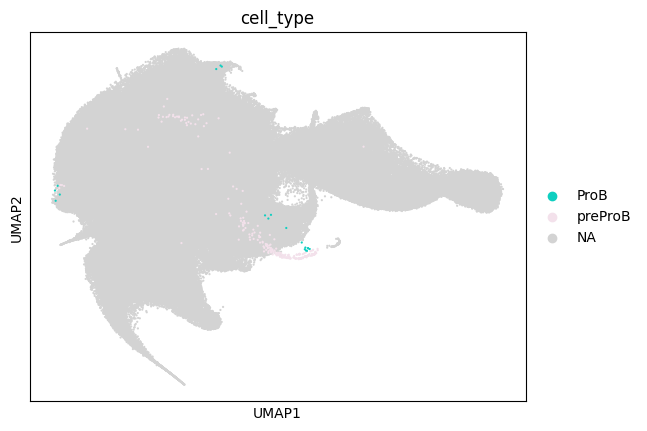

In [227]:
sc.pl.umap(adata_loop2, color="cell_type", groups=["preProB", "ProB"], s=10)

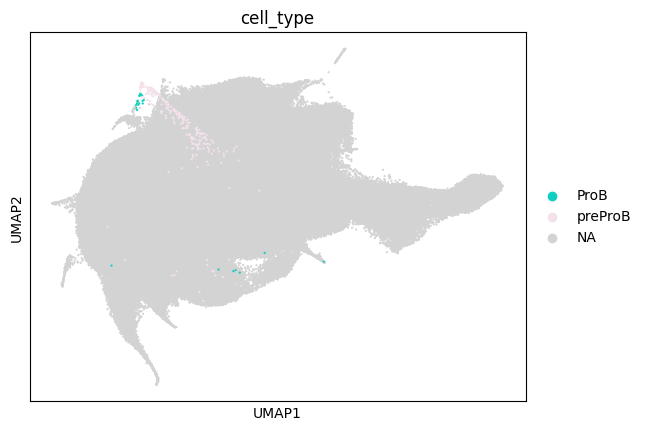

In [228]:
sc.pl.umap(adata_loop2p5, color="cell_type", groups=["preProB", "ProB"], s=10)

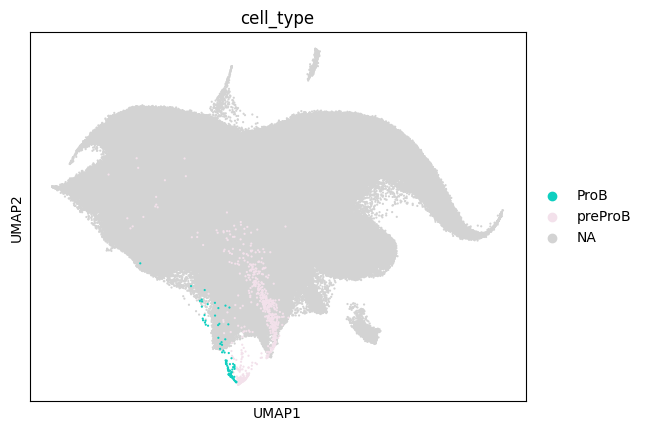

In [229]:
sc.pl.umap(adata_loop3, color="cell_type", s=10, groups=["preProB", "ProB"])

## Check proB proportions 

In [72]:
prob_protocols_to_keep = ["245", "246", "251", "252", "253"]

In [93]:
number_of_b_per_protocol = {}
cd19_per_protocol = {"protocol": [], "marker_val": []}


def get_b_cells(adata, exp):
    adata_protocol = adata[
        (adata.obs.cell_type.isin(["preProB", "ProB"])) &
        (adata.obs.experiment_number == exp)
    ]
    return adata_protocol, adata_protocol.n_obs


def get_marker_values(adata_protocol, marker="CD19"):
    return adata_protocol[:, marker].X.toarray().squeeze()


for exp in prob_protocols_to_keep:

    if exp in ["245", "246"]:
        adata_source = adata_loop2
    elif exp == "251":
        adata_source = adata_loop2p5
    else:
        adata_source = adata_loop3

    adata_protocol, counts_b = get_b_cells(adata_source, exp)
    cd19_expr = get_marker_values(adata_protocol, "CD19")

    number_of_b_per_protocol[exp] = counts_b

    cd19_per_protocol["protocol"].extend([exp] * len(cd19_expr))
    cd19_per_protocol["marker_val"].extend(cd19_expr)

In [94]:
cd19_per_protocol["marker_val"] = np.concatenate(cd19_per_protocol["marker_val"])

In [95]:
cd19_per_protocol_df = pd.DataFrame(cd19_per_protocol)

<Axes: xlabel='protocol', ylabel='marker_val'>

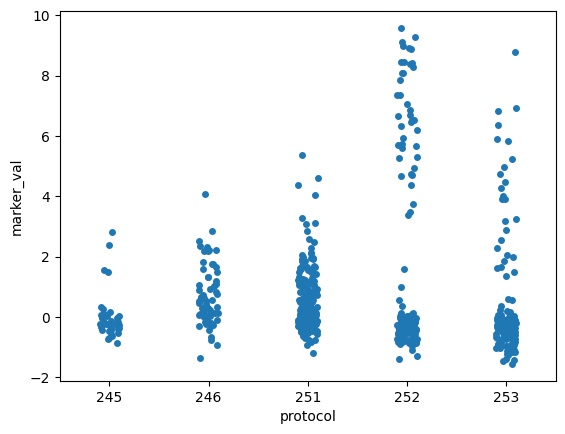

In [101]:
sns.stripplot(cd19_per_protocol_df, x="protocol", y="marker_val")

## Repeat the analysis with whole dataset 

In [137]:
prob_protocols_to_keep = ["245", "252", "253"]

In [132]:
adata_loop3 = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop3/replicate/adata_full.h5ad")

# del adata_loop2p5
# del adata_loop3

In [138]:
adata_loop3.shape

(4924516, 20)

In [139]:
mask = adata_loop3.obs.experiment_number.isin(prob_protocols_to_keep)

In [140]:
adata_loop3 = adata_loop3[mask]

In [141]:
adata_loop3

View of AnnData object with n_obs × n_vars = 4058042 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'il7_[ng_ml]', 'mcsf_[ng_ml]', 'ly_cocktail_[ul/well]'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps'
    layers: 'positives', '

In [142]:
cd19_per_protocol = {}

cd19_per_protocol["protocol"] = adata_loop3.obs.experiment_number 
cd19_per_protocol["marker_val"] = adata_loop3[:, "CD19"].X.toarray().squeeze()

cd19_per_protocol_df = pd.DataFrame(cd19_per_protocol)

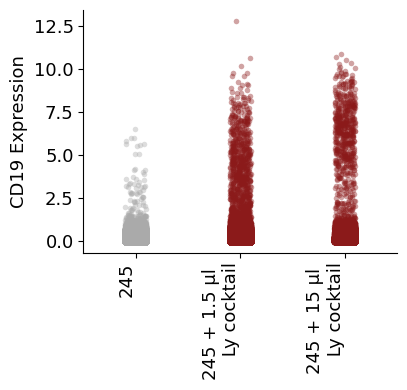

In [215]:
fig, ax = plt.subplots(figsize=(4, 4))

plot_df = cd19_per_protocol_df[
    cd19_per_protocol_df.marker_val > cd19_per_protocol_df.marker_val.quantile(0.75)
].copy()

name_map = {
    245: "245",
    253: "245 + 1.5 μl \n Ly cocktail",
    252: "245 + 15 μl \n Ly cocktail",
}
order = [245, 253, 252]
highlight_protocols = [252, 253]
colors = ["#8B1A1A" if exp in highlight_protocols else "#AAAAAA" for exp in order]

sns.stripplot(
    data=plot_df,
    x="protocol", y="marker_val",
    order=order,
    color="#AAAAAA",  # default, we'll override below
    size=4,
    alpha=0.4,
    jitter=True,
    ax=ax
)

# Recolor each group's points manually
for i, col in enumerate(colors):
    ax.collections[i].set_facecolor(col)

ax.set_xticks(range(len(order)))
ax.set_xticklabels([name_map[p] for p in order], fontsize=13, rotation=90, ha='right')
ax.set_xlabel("", fontsize=13) 
ax.set_ylabel("CD19 Expression", fontsize=13)
ax.tick_params(axis='y', labelsize=13)
sns.despine()
plt.tight_layout()
fig.savefig("cd19_per_protocol.png", dpi=300, bbox_inches='tight')
plt.show()

## Plot 

/tmp/ipykernel_3717037/4255673525.py:8: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


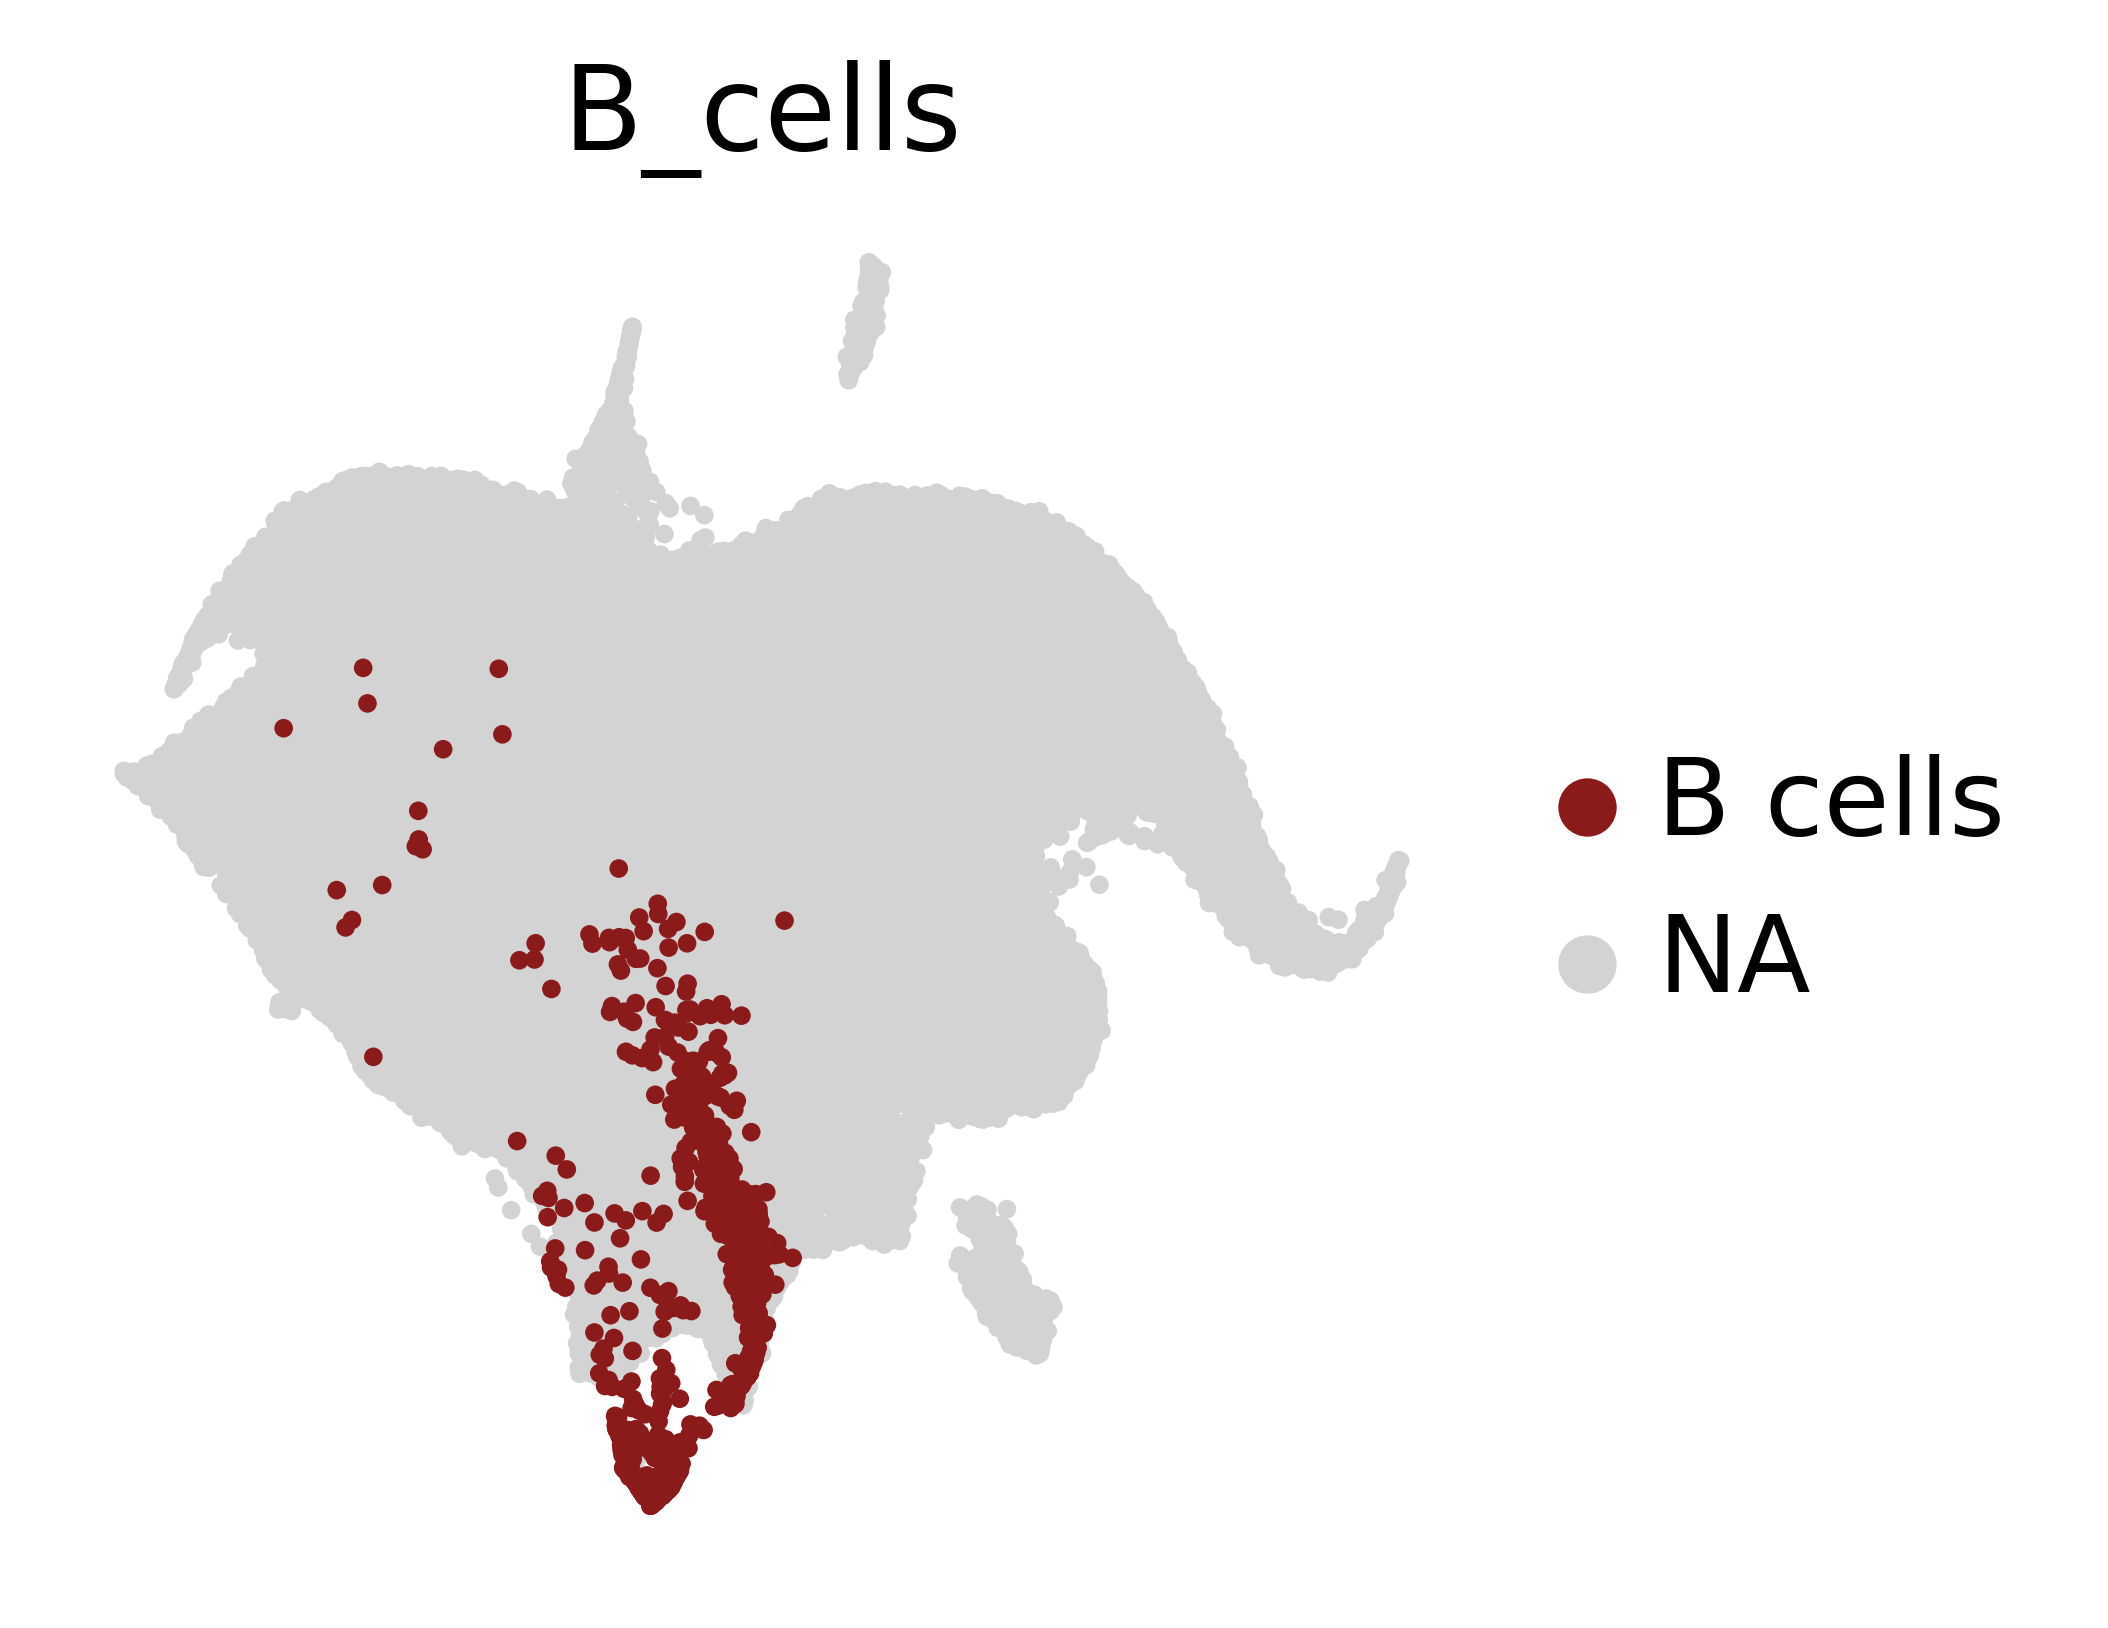

In [248]:
adata_loop3.obs["B_cells"] = adata_loop3.obs["cell_type"].apply(
    lambda x: "B cells" if x in ["preProB", "ProB"] else "other"
)
sc.set_figure_params(dpi=300)


with rc_context({"figure.figsize": (3, 3)}):
    sc.pl.umap(
        adata_loop3,
        color="B_cells",
        s=20,
        groups=["B cells"],
        palette={"B cells": "#8B1A1A", "other": "#DDDDDD"},
        frameon=False,
        save="_b_cells.png"
    )


## Experiment with heatmaps 